In [203]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [204]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [205]:
cd /content/gdrive/MyDrive/Colab_Notebooks/Projet

/content/gdrive/MyDrive/Colab_Notebooks/Projet


In [206]:
df = pd.read_csv("diabetes.csv")
print(f"Dimensions du dataset : {df.shape}")
print("\nPremières lignes :")
display(df.head())
print("\nInformations générales :")
df.info()
print("\nStatistiques descriptives :")
display(df.describe(include='all'))

Dimensions du dataset : (768, 9)

Premières lignes :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistiques descriptives :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [207]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [208]:
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [209]:
print(df.isnull().any(axis=1).sum())

0


In [210]:
duplicates = df.duplicated().sum()
print("Num des doublons:", duplicates)
df=df.drop_duplicates()
print(df.shape)

Num des doublons: 0
(768, 9)


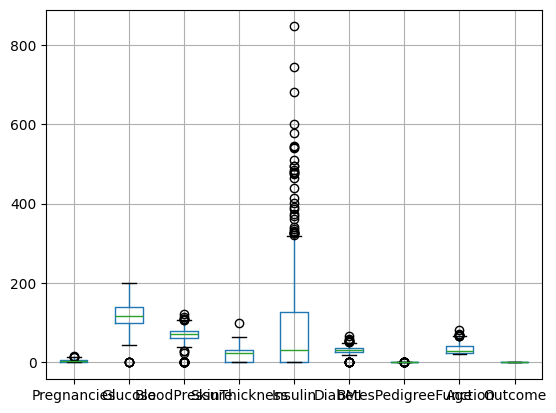

In [211]:
df.boxplot(column=["Pregnancies",	"Glucose",	"BloodPressure",	"SkinThickness",	"Insulin",	"BMI",	"DiabetesPedigreeFunction",	"Age",	"Outcome"])
plt.show()

In [212]:
correlation_matrix = df.corr()
display(correlation_matrix)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


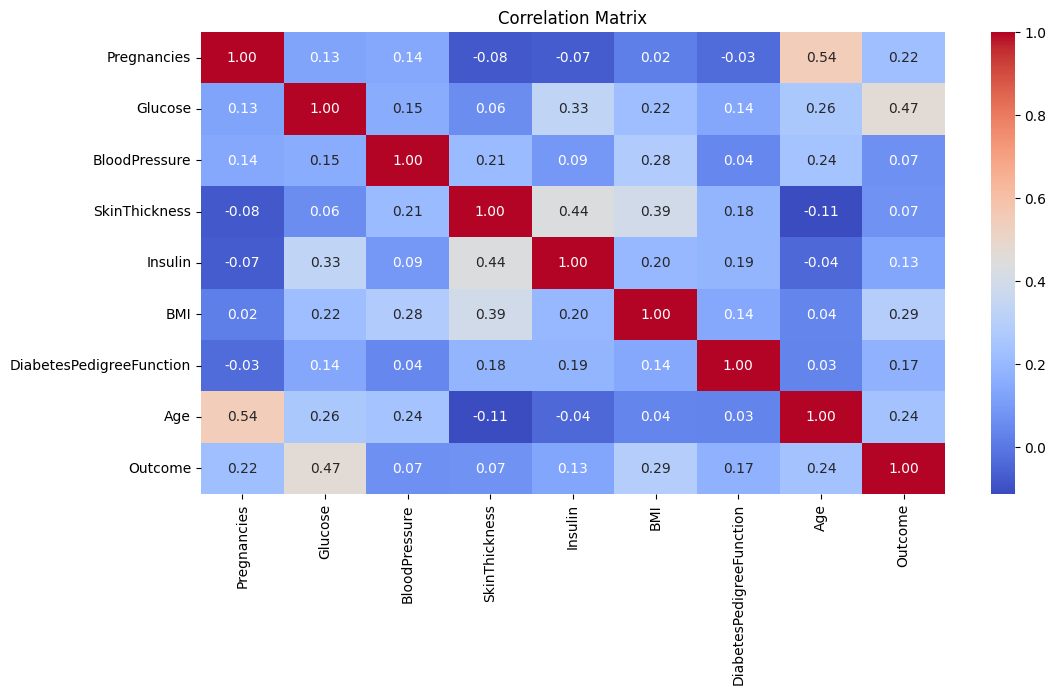

In [213]:
plt.figure(figsize=(12,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

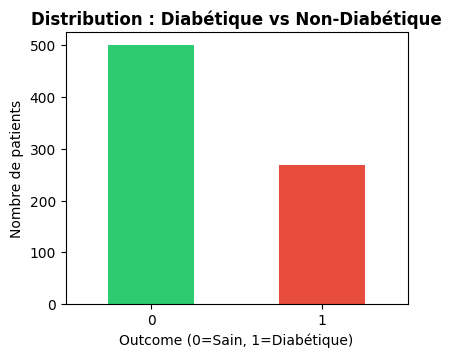

In [214]:
plt.figure(figsize=(15, 12))

plt.subplot(3, 3, 1)
df['Outcome'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribution : Diabétique vs Non-Diabétique', fontsize=12, fontweight='bold')
plt.xlabel('Outcome (0=Sain, 1=Diabétique)')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)

In [215]:
from imblearn.over_sampling import SMOTE

X = df.drop('Outcome', axis=1)
y = df['Outcome']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"✅ Avant SMOTE : {sum(y == 0)} sains, {sum(y == 1)} diabétiques")
print(f"✅ Après SMOTE : {sum(y_resampled == 0)} sains, {sum(y_resampled == 1)} diabétiques")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

✅ Avant SMOTE : 500 sains, 268 diabétiques
✅ Après SMOTE : 500 sains, 500 diabétiques


In [216]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [217]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [218]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
print(X_train_scaled_df.shape)
display(X_train_scaled_df)
print(X_test_scaled_df.shape)
display(X_test_scaled_df)

(800, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
859,0.635155,0.993892,-0.861841,0.703334,0.777296,-0.093729,0.846946,0.355911
475,-1.195923,0.362549,0.762598,0.390045,-0.717401,-0.710621,-0.803342,2.219782
749,0.635155,1.151728,-0.354204,-1.301717,-0.717401,-1.110453,-0.962441,1.420980
608,-1.195923,0.836056,0.661071,1.141939,1.619138,1.181919,-0.686268,-0.620403
794,1.245514,-0.237227,-0.506495,-1.301717,-0.717401,-0.299323,1.280964,-0.087868
...,...,...,...,...,...,...,...,...
225,-0.890743,-1.215809,0.458016,0.390045,-0.442514,0.262305,-1.193586,-1.064182
956,-1.195923,-0.079391,-3.501556,-1.301717,-0.717401,0.459388,-0.941607,-0.886670
375,2.466233,0.457250,0.661071,1.392570,2.074419,0.875381,0.088218,2.131026
382,-0.890743,-0.521332,-0.455732,-0.800454,0.846018,-0.963848,1.346007,-1.152938


(200, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
907,2.161053,-0.994839,-0.354204,-0.863112,1.507465,-0.642656,1.215072,0.888445
469,0.635155,0.899190,0.458016,1.267255,0.485229,1.794996,0.217299,-0.620403
351,0.024796,0.362549,0.762598,-1.301717,-0.717401,-0.190839,-0.740302,-0.354136
89,-0.890743,-0.584466,-0.049622,-0.111218,-0.717401,-0.817243,-1.001466,-0.886670
300,-1.195923,1.309563,-3.501556,-1.301717,-0.717401,-0.044233,1.021803,-0.354136
...,...,...,...,...,...,...,...,...
836,-1.195923,-0.079391,0.051906,-0.048560,-0.717401,-0.651590,-0.649005,0.089643
19,-0.890743,-0.331929,0.051906,0.578019,0.107260,0.262305,0.091220,-0.176624
531,-1.195923,-0.584466,0.356488,-1.301717,-0.717401,1.688374,0.562515,-0.886670
243,0.635155,-0.205660,-0.963369,0.076756,0.794477,-0.737276,2.459705,-0.087868


In [219]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Nombre de composantes conservées : {pca.n_components_}")
print(f"Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.3f}")

Nombre de composantes conservées : 7
Variance expliquée cumulée : 0.955


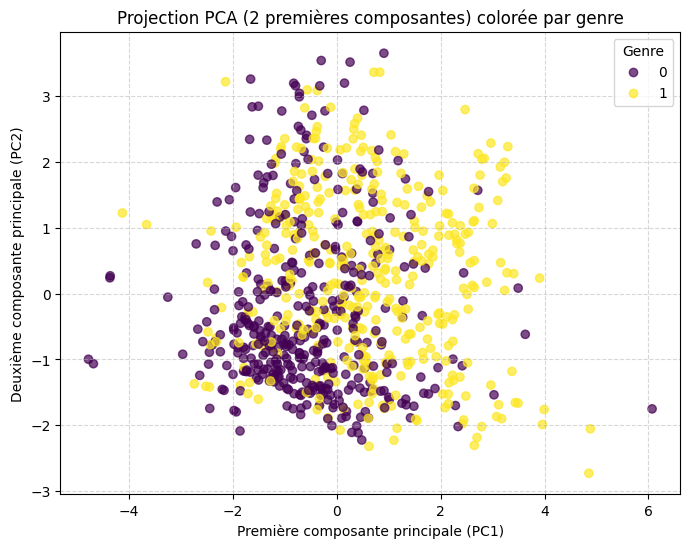

In [220]:
import matplotlib.pyplot as plt

X_pca_full = pca.transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_full[:, 0],
    X_pca_full[:, 1],
    c=y_train,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Première composante principale (PC1)')
plt.ylabel('Deuxième composante principale (PC2)')
plt.title('Projection PCA (2 premières composantes) colorée par genre')
plt.legend(*scatter.legend_elements(), title="Genre")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [221]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

In [222]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [223]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf','linear']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure score CV :", grid_search.best_score_)

y_pred_best = grid_search.best_estimator_.predict(X_test_scaled)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Meilleurs paramètres : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Meilleure score CV : 0.80625


In [224]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import pandas as pd

def evaluate_model(y_true, y_pred, model_name):
    return {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

results = []
results.append(evaluate_model(y_test, y_pred_linear, 'SVM Linéaire'))
results.append(evaluate_model(y_test, y_pred_rbf, 'SVM RBF (défaut)'))
results.append(evaluate_model(y_test, y_pred_best, 'SVM RBF (GridSearch)'))

results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Modèle  Accuracy  Precision  Recall  F1-score
0          SVM Linéaire      0.73     0.7500    0.69    0.7188
1      SVM RBF (défaut)      0.76     0.7453    0.79    0.7670
2  SVM RBF (GridSearch)      0.82     0.8137    0.83    0.8218


In [225]:
!pip install catboost

In [226]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy :      {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision :     {precision_score(y_test, y_pred):.4f}")
print(f"Recall :        {recall_score(y_test, y_pred):.4f}")
print(f"F1-score :      {f1_score(y_test, y_pred):.4f}")
print(f"AUC (ROC) :     {roc_auc_score(y_test, y_proba):.4f}")

Accuracy :      0.8050
Precision :     0.7798
Recall :        0.8500
F1-score :      0.8134
AUC (ROC) :     0.8912


In [227]:
from sklearn.ensemble import RandomForestClassifier
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_grid.fit(X_train_scaled, y_train)

print(f"✅ Meilleurs paramètres : {rf_grid.best_params_}")
print(f"✅ Meilleur score (AUC) : {rf_grid.best_score_:.4f}")

✅ Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Meilleur score (AUC) : 0.8950


In [228]:
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
"""print(y_pred[:10])"""
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :")
print(cm)


Matrice de confusion :
[[78 22]
 [14 86]]


In [229]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
import numpy as np

# Probabilités de la classe "Diabétique"
y_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

# Trouver le seuil optimal (maximise Sensibilité + Spécificité)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]

print(f"Seuil optimal (Youden) : {best_threshold:.3f}")

# Prédiction avec seuil ajusté
y_pred_opt = (y_proba >= best_threshold).astype(int)

# Nouvelle matrice de confusion
cm_opt = confusion_matrix(y_test, y_pred_opt)
print("\nMatrice de confusion (seuil optimisé) :")
print(cm_opt)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_opt))

Seuil optimal (Youden) : 0.530

Matrice de confusion (seuil optimisé) :
[[82 18]
 [14 86]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       100
           1       0.83      0.86      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [230]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

scores = cross_val_score(
    rf_grid.best_estimator_,
    X_train_scaled,
    y_train,
    cv=15,
    scoring='roc_auc',
    n_jobs=-1
)

print(scores)
print("Moyenne :", scores.mean())
print("Écart-type :", scores.std())

[0.89506173 0.9122085  0.93278464 0.85596708 0.90466392 0.88319088
 0.88176638 0.89458689 0.86965812 0.93660969 0.91880342 0.95512821
 0.90527066 0.82977208 0.8468661 ]
Moyenne : 0.8948225528472442
Écart-type : 0.03355361790667242


In [231]:
# Obtenir le meilleur modèle entraîné
best_model = rf_grid.best_estimator_

# Maintenant tu peux extraire les importances
importances = best_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

important_features = feature_importance_df[feature_importance_df['Importance'] > 0.068]
print("\nFeatures importantes (> 0.07) :")
print(important_features)

                    Feature  Importance
1                   Glucose    0.265412
5                       BMI    0.175104
7                       Age    0.141573
6  DiabetesPedigreeFunction    0.119682
2             BloodPressure    0.091195
3             SkinThickness    0.069922
0               Pregnancies    0.069358
4                   Insulin    0.067754

Features importantes (> 0.07) :
                    Feature  Importance
1                   Glucose    0.265412
5                       BMI    0.175104
7                       Age    0.141573
6  DiabetesPedigreeFunction    0.119682
2             BloodPressure    0.091195
3             SkinThickness    0.069922
0               Pregnancies    0.069358


In [232]:
print("\n[2/3] Random Forest avec GridSearchCV...")
important_cols = important_features['Feature'].tolist()
X_train_selected = X_train[important_cols]
X_test_selected  = X_test[important_cols]
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf1 = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_grid1 = GridSearchCV(rf1, rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_grid1.fit(X_train_selected, y_train)

print(f"✅ Meilleurs paramètres : {rf_grid1.best_params_}")
print(f"✅ Meilleur score (AUC) : {rf_grid1.best_score_:.4f}")


[2/3] Random Forest avec GridSearchCV...
✅ Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Meilleur score (AUC) : 0.8930


In [233]:
from sklearn.neighbors import KNeighborsClassifier
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
knn_grid.fit(X_train_scaled, y_train)

print(f"✅ Meilleurs paramètres : {knn_grid.best_params_}")
print(f"✅ Meilleur score (AUC) : {knn_grid.best_score_:.4f}")

✅ Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
✅ Meilleur score (AUC) : 0.8674


In [234]:
# 7. MODÈLE FINAL OPTIMISÉ
best_model = rf_grid.best_estimator_
y_pred_final = best_model.predict(X_test_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 60)
print("PERFORMANCES MODÈLE OPTIMISÉ")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")

print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Pas diabète', 'Diabète']))


PERFORMANCES MODÈLE OPTIMISÉ

Accuracy: 0.8200
Precision: 0.7963
Recall: 0.8600
F1-Score: 0.8269
ROC-AUC: 0.9204

RAPPORT DE CLASSIFICATION DÉTAILLÉ
              precision    recall  f1-score   support

 Pas diabète       0.85      0.78      0.81       100
     Diabète       0.80      0.86      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [235]:
import joblib

joblib.dump(best_model, 'diabetes.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

In [236]:
# predict_diabetes.py
import joblib

# 📥 Charger les artefacts
print("Chargement du modèle...")
model = joblib.load('diabetes.pkl')
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl')

print("✅ Modèle chargé avec succès !\n")

# 📥 Saisie utilisateur
print("Entrez les caractéristiques du patient :")
print("(Plages typiques)")
print("- Grossesses : 0-17")
print("- Glucose : 50-200 mg/dL")
print("- Pression artérielle : 30-130 mm Hg")
print("- Épaisseur peau : 0-100 mm")
print("- Insuline : 0-850 mu U/ml")
print("- IMC : 15-60")
print("- Facteur génétique : 0.0-2.4")
print("- Âge : 20-80 ans")
print()

# Récupérer les valeurs dans le bon ordre
inputs = {}
for feature in feature_names:
    value = float(input(f"Entrez {feature} : "))
    inputs[feature] = value

# Transformer en array dans le bon ordre
import numpy as np
input_array = np.array([[inputs[feature] for feature in feature_names]])

# Appliquer le même scaling que lors de l'entraînement
input_scaled = scaler.transform(input_array)

# 🔮 Prédiction
prediction = model.predict(input_scaled)[0]
prediction_proba = model.predict_proba(input_scaled)[0]

# 📤 Résultats
print("\n" + "="*50)
print("RÉSULTAT DE LA PRÉDICTION")
print("="*50)
outcome = "Diabétique" if prediction == 1 else "Non diabétique"
print(f"Prédiction : {outcome}")
print(f"Probabilité :")
print(f"  - Non diabétique : {prediction_proba[0]:.4f} ({prediction_proba[0]*100:.2f}%)")
print(f"  - Diabétique     : {prediction_proba[1]:.4f} ({prediction_proba[1]*100:.2f}%)")

if prediction == 1:
    print("\n⚠️  Risque élevé de diabète. Consultez un professionnel de santé.")
else:
    print("\n✅ Risque faible de diabète.")

Chargement du modèle...
✅ Modèle chargé avec succès !

Entrez les caractéristiques du patient :
(Plages typiques)
- Grossesses : 0-17
- Glucose : 50-200 mg/dL
- Pression artérielle : 30-130 mm Hg
- Épaisseur peau : 0-100 mm
- Insuline : 0-850 mu U/ml
- IMC : 15-60
- Facteur génétique : 0.0-2.4
- Âge : 20-80 ans

Entrez Pregnancies : 10
Entrez Glucose : 80
Entrez BloodPressure : 100
Entrez SkinThickness : 20
Entrez Insulin : 100
Entrez BMI : 30
Entrez DiabetesPedigreeFunction : 0.6
Entrez Age : 50

RÉSULTAT DE LA PRÉDICTION
Prédiction : Non diabétique
Probabilité :
  - Non diabétique : 0.6800 (68.00%)
  - Diabétique     : 0.3200 (32.00%)

✅ Risque faible de diabète.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
